## 6. Deployment

What runs where, and what has and hasn't been deployed:

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

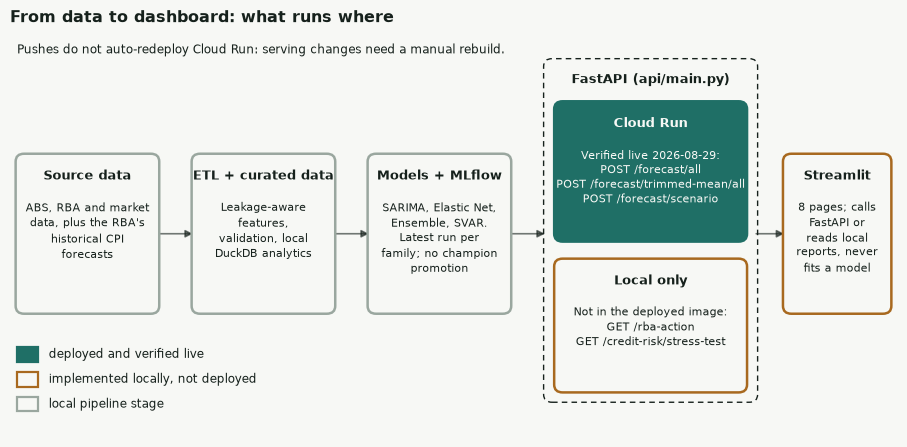

In [2]:
import textwrap
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.set_xlim(0, 12.6)
ax.set_ylim(0, 6.2)
ax.axis("off")

def box(x, y, w, h, title, body, kind, wrap=22, size=8.2):
    style = {"live": dict(fc=ACCENT, ec=ACCENT, tc=PAPER, hatch=None),
             "local": dict(fc=PAPER, ec=HIGHLIGHT, tc=INK, hatch=None),
             "pipe": dict(fc=PAPER, ec=MUTED, tc=INK, hatch=None)}[kind]
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.12", facecolor=style["fc"],
                                edgecolor=style["ec"], linewidth=1.8, zorder=2))
    ax.text(x + w / 2, y + h - 0.22, title, ha="center", va="top", fontsize=9.5, fontweight="bold", color=style["tc"], zorder=3)
    ax.text(x + w / 2, y + h - 0.68, "\n".join(textwrap.fill(p, wrap, break_on_hyphens=False) for p in body.split("\n")),
            ha="center", va="top", fontsize=size, color=style["tc"], zorder=3, linespacing=1.35)

def arrow(x0, x1, y=3.1):
    ax.annotate("", xy=(x1, y), xytext=(x0, y), zorder=1,
                arrowprops=dict(arrowstyle="-|>", color=INK, alpha=0.6, lw=1.2, shrinkA=0, shrinkB=0))

box(0.1, 1.9, 2.0, 2.4, "Source data", "ABS, RBA and market data, plus the RBA's historical CPI forecasts", "pipe", wrap=20)
box(2.6, 1.9, 2.0, 2.4, "ETL + curated data", "Leakage-aware features, validation, local DuckDB analytics", "pipe", wrap=20)
box(5.1, 1.9, 2.0, 2.4, "Models + MLflow", "SARIMA, Elastic Net, Ensemble, SVAR. Latest run per family; no champion promotion", "pipe", wrap=20)
for a, b in ((2.1, 2.6), (4.6, 5.1)):
    arrow(a, b)

# FastAPI: two stacked sub-boxes, deployed vs local
ax.add_patch(FancyBboxPatch((7.6, 0.55), 3.0, 5.2, boxstyle="round,pad=0.02,rounding_size=0.12", facecolor="none",
                            edgecolor=INK, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1))
ax.text(9.1, 5.55, "FastAPI (api/main.py)", ha="center", va="top", fontsize=9.5, fontweight="bold")
box(7.75, 3.0, 2.7, 2.1, "Cloud Run", "Verified live 2026-08-29:\nPOST /forecast/all\nPOST /forecast/trimmed-mean/all\nPOST /forecast/scenario", "live", wrap=36, size=7.8)
box(7.75, 0.7, 2.7, 2.0, "Local only", "Not in the deployed image:\nGET /rba-action\nGET /credit-risk/stress-test", "local", wrap=36, size=7.8)
arrow(7.1, 7.6)
box(11.0, 1.9, 1.5, 2.4, "Streamlit", "8 pages; calls FastAPI or reads local reports, never fits a model", "local", wrap=14, size=8)
arrow(10.6, 11.0)

# legend
lx, ly = 0.1, 1.15
for i, (fc, ec, text) in enumerate([(ACCENT, ACCENT, "deployed and verified live"),
                                    (PAPER, HIGHLIGHT, "implemented locally, not deployed"),
                                    (PAPER, MUTED, "local pipeline stage")]):
    ax.add_patch(plt.Rectangle((lx, ly - 0.38 * i), 0.3, 0.22, facecolor=fc, edgecolor=ec, linewidth=1.6))
    ax.text(lx + 0.45, ly - 0.38 * i + 0.11, text, va="center", fontsize=8.3)
ax.text(0.1, 5.85, "Pushes do not auto-redeploy Cloud Run: serving changes need a manual rebuild.", fontsize=8.5)
ax.set_title("From data to dashboard: what runs where", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()

- **FastAPI on Cloud Run:** redeployed and verified live 2026-08-29, serving
  `/forecast/all`, `/forecast/trimmed-mean/all`, and `/forecast/scenario` from baked local
  MLflow runs. Pushes do not auto-redeploy; manual rebuild required after serving changes.
- **`GET /rba-action`** and **`GET /credit-risk/stress-test`:** implemented locally in
  `api/main.py` after that verified image; not yet part of the deployed Cloud Run image.
- **Streamlit:** Overview, Data Explorer, EDA Dashboard, Forecasts (headline/trimmed-mean
  toggle), Scenario Explorer, RBA Policy, Methodology, Diagnostics. Every page calls
  FastAPI or reads a local report; none fit models in-process.
- **No MLflow champion/registry promotion:** `/forecast/all` serves every family's latest
  finished run directly; there is no promoted "best" model.